# Solution for exercise 5
In this exercise you will:
- Train regression and classification models using random forests.
- Visualize individual trees
- Check feature importances
- Get general classification metrics including area under the curve.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc # different metrics 
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # RF model
from sklearn.tree import plot_tree # function to visualize a decision tree

In [3]:
data = pd.read_csv('wines.csv') # Note: there are missing values and many more white wines than red wines...
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### Clean the dataset

In [4]:
# Are there missing values? Here, .sum() sums all samples with missing values PER COLUMN
data.isna().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [5]:
data = data.dropna() # remove samples with missing values (we could also replace missing values by column averages)
data.shape # check how many samples (rows) are there after removing missing values (originally there were 6497 samples)

(6463, 13)

### Get white and red wines separately

In [6]:
data['type'] == 'white' # This is a mask to get where are the white wines

0        True
1        True
2        True
3        True
4        True
        ...  
6491    False
6492    False
6494    False
6495    False
6496    False
Name: type, Length: 6463, dtype: bool

In [7]:
mask_white = data['type'] == 'white' # save the mask as object mask_white
mask_white # check the mask

0        True
1        True
2        True
3        True
4        True
        ...  
6491    False
6492    False
6494    False
6495    False
6496    False
Name: type, Length: 6463, dtype: bool

In [8]:
mask_red = data['type'] == 'red' # save the mask as object mask_red
mask_red # check the mask

0       False
1       False
2       False
3       False
4       False
        ...  
6491     True
6492     True
6494     True
6495     True
6496     True
Name: type, Length: 6463, dtype: bool

In [9]:
mask_white.sum() , mask_red.sum() # total number of white and red wines (= number of Trues in each mask) 
# The dataset is UNBALANCED!! 4870 whites + 1593 reds

(np.int64(4870), np.int64(1593))

In [10]:
# let's separate whites and reds into two different dataframes
whites = data[mask_white]
reds = data[mask_red]

In [11]:
# get (randomly) only 1593 white wines (to achieve a balanced dataset)
whites = whites.sample(n = 1593)

In [12]:
whites.describe() # note that statistics were not shown for the first column (='white')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000
mean,6.863685,0.278365,0.331475,6.509291,0.045429,35.631199,138.361582,0.994063,3.185530,0.488544,10.512295,5.901444
std,0.836995,0.101910,0.119628,5.148148,0.021074,16.357915,42.232035,0.003116,0.155905,0.115653,1.250686,0.886642
min,4.200000,0.080000,0.000000,0.700000,0.014000,2.000000,24.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.210000,0.260000,1.800000,0.036000,24.000000,110.000000,0.991740,3.080000,0.410000,9.400000,5.000000
50%,6.800000,0.260000,0.310000,5.600000,0.043000,34.000000,133.000000,0.993800,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.330000,0.390000,10.050000,0.050000,46.000000,166.000000,0.996280,3.280000,0.550000,11.400000,6.000000
max,14.200000,0.965000,1.000000,65.800000,0.346000,131.000000,366.500000,1.038980,3.810000,1.080000,14.200000,9.000000


In [13]:
reds.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000
mean,8.326365,0.527659,0.271551,2.538512,0.087497,15.841808,46.463905,0.996752,3.310590,0.657866,10.419617,5.636535
std,1.740681,0.179297,0.194843,1.412061,0.047134,10.436038,32.913696,0.001888,0.154305,0.169716,1.065206,0.807687
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997850,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


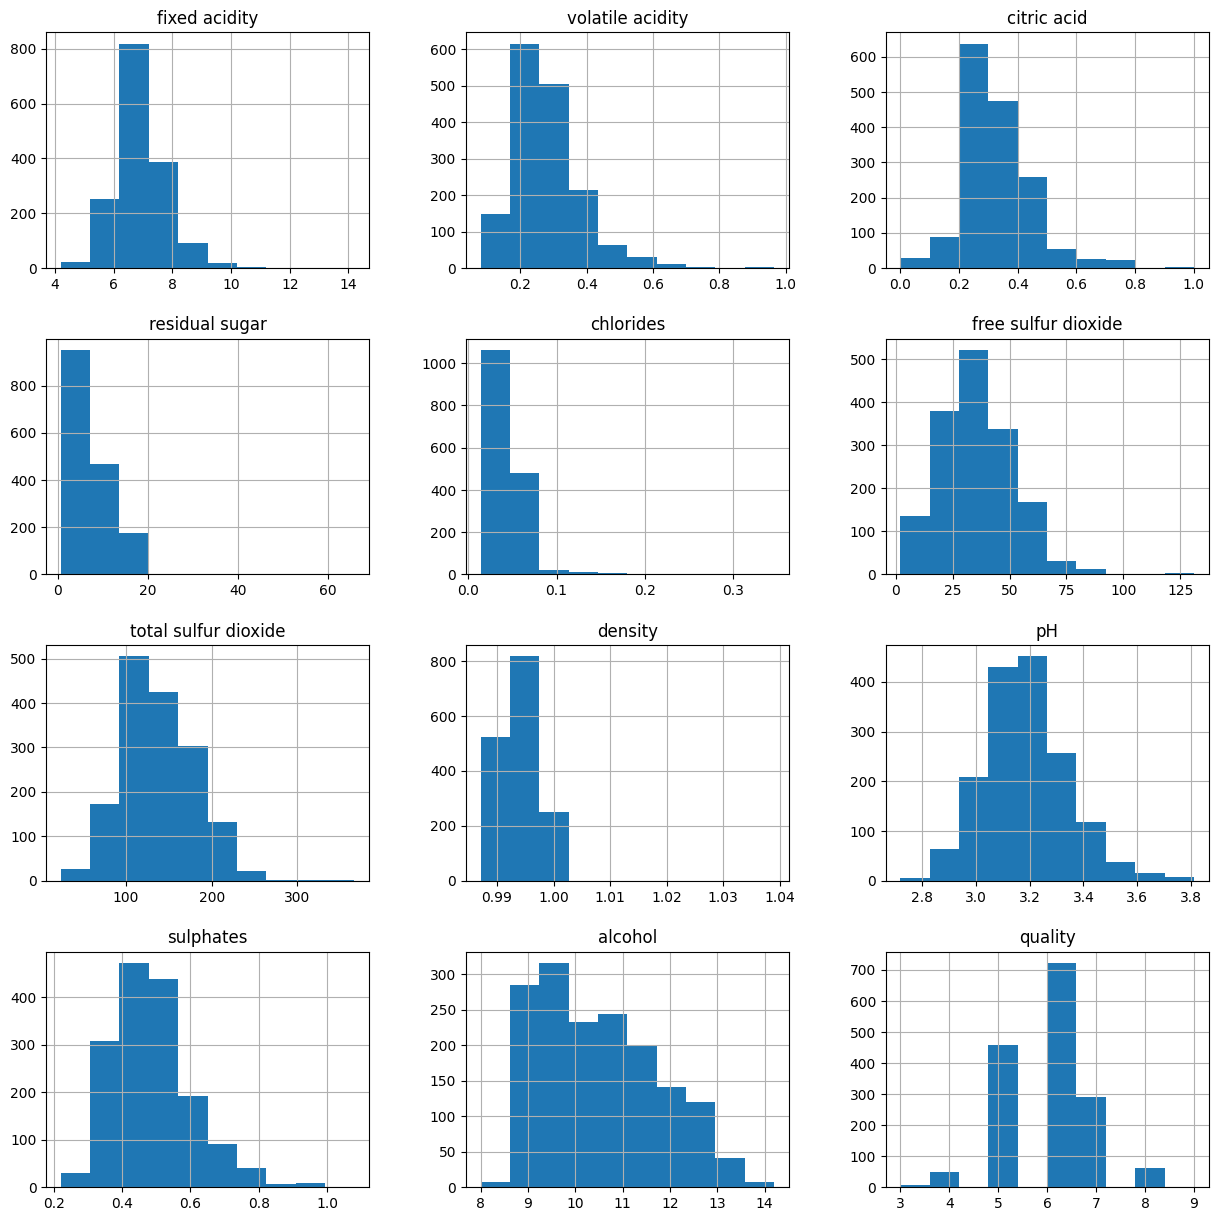

In [14]:
# check histograms of individual columns 
whites.hist(figsize=(15,15));

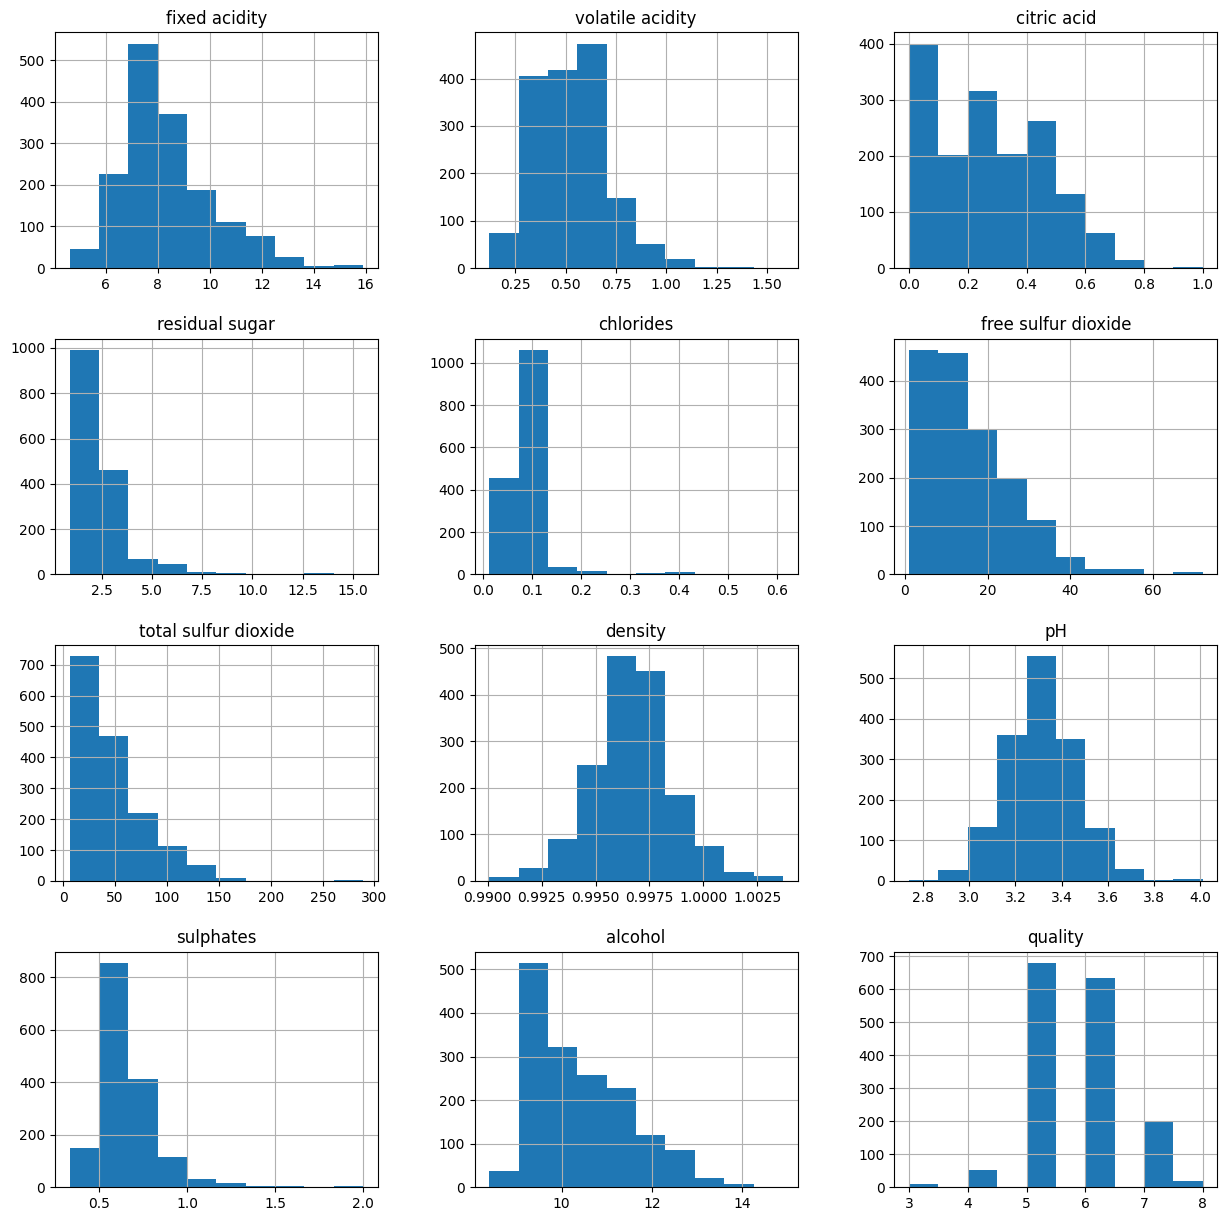

In [15]:
# check histograms of individual columns 
reds.hist(figsize=(15,15));
# the histograms of whites and reds seem to be very similar (=features are balanced)

### Reunify clean + balanced subsets

In [16]:
# final DataFrame with balanced reds and whites, no missing values
data_cured = pd.concat([reds, whites]) # reds and whites are concatenated into DataFrame "data" 

In [17]:
data_cured

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4898,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
4899,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
4900,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
4901,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4902,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,white,8.3,0.40,0.38,1.1,0.038,15.0,75.0,0.9934,3.03,0.43,9.2,5
1410,white,7.1,0.26,0.32,5.9,0.037,39.0,97.0,0.9934,3.31,0.40,11.6,6
72,white,6.0,0.27,0.28,4.8,0.063,31.0,201.0,0.9964,3.69,0.71,10.0,5
529,white,5.6,0.19,0.47,4.5,0.030,19.0,112.0,0.9922,3.56,0.45,11.2,6


In [18]:
# Let's shuffle the DataFrame
data_cured = data_cured.sample(frac = 1) # frac = fraction of rows to be shuffled (or "sampled"). Here, 1 = 100% of samples (rows)

In [19]:
data_cured

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
5305,red,12.0,0.39,0.66,3.00,0.093,12.0,30.0,0.99960,3.18,0.63,10.8,7
72,white,6.0,0.27,0.28,4.80,0.063,31.0,201.0,0.99640,3.69,0.71,10.0,5
5306,red,10.4,0.34,0.58,3.70,0.174,6.0,16.0,0.99700,3.19,0.70,11.3,6
3669,white,5.9,0.37,0.32,1.60,0.029,41.0,102.0,0.98916,3.41,0.55,12.7,7
4912,red,8.9,0.62,0.18,3.80,0.176,52.0,145.0,0.99860,3.16,0.88,9.2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,white,6.4,0.21,0.34,16.05,0.040,56.0,142.0,0.99678,3.11,0.38,10.6,5
5105,red,7.8,0.57,0.31,1.80,0.069,26.0,120.0,0.99625,3.29,0.53,9.3,5
6083,red,7.0,0.43,0.30,2.00,0.085,6.0,39.0,0.99346,3.33,0.46,11.9,6
5952,red,8.2,0.64,0.27,2.00,0.095,5.0,77.0,0.99747,3.13,0.62,9.1,6



# PART 1: Prediction of wine type (class = "white" or "red")


In [20]:
# the target vector will be the column "type"
X = data_cured.drop(['type'], axis = 1) # features are all columns except the target column
y = data_cured['type'] # classes (=white or red)

In [21]:
# check the features
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
5305,12.0,0.39,0.66,3.00,0.093,12.0,30.0,0.99960,3.18,0.63,10.8,7
72,6.0,0.27,0.28,4.80,0.063,31.0,201.0,0.99640,3.69,0.71,10.0,5
5306,10.4,0.34,0.58,3.70,0.174,6.0,16.0,0.99700,3.19,0.70,11.3,6
3669,5.9,0.37,0.32,1.60,0.029,41.0,102.0,0.98916,3.41,0.55,12.7,7
4912,8.9,0.62,0.18,3.80,0.176,52.0,145.0,0.99860,3.16,0.88,9.2,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3209,6.4,0.21,0.34,16.05,0.040,56.0,142.0,0.99678,3.11,0.38,10.6,5
5105,7.8,0.57,0.31,1.80,0.069,26.0,120.0,0.99625,3.29,0.53,9.3,5
6083,7.0,0.43,0.30,2.00,0.085,6.0,39.0,0.99346,3.33,0.46,11.9,6
5952,8.2,0.64,0.27,2.00,0.095,5.0,77.0,0.99747,3.13,0.62,9.1,6


In [22]:
# check the target property. First column = index of the sample in the original(imported) DataFrame
y

5305      red
72      white
5306      red
3669    white
4912      red
        ...  
3209    white
5105      red
6083      red
5952      red
4212    white
Name: type, Length: 3186, dtype: object

#### split the dataset

In [23]:
# we only use random_state to be able to split again X and y to generate precisely the same samples
# in X_train, y_train, etc.  Note that the function train_test_split() shuffles all rows of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y) # stratify: get balanced subsets!

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((2548, 12), (638, 12), (2548,), (638,))

In [25]:
(y_test == 'white').sum() # you have precisely half of the test set for each class! (your dataset is balanced)

np.int64(319)

#### Preprocessing

In [26]:
# Let's preprocess the features
scaler = StandardScaler()
scaler.fit(X_train) #mean and std of each feature of X_train are stored inside object "scaler"
X_train_s = scaler.transform(X_train) # convert X_train into zero mean and unit variance
X_test_s = scaler.transform(X_test) # convert X_test into zero mean and unit variance

#### Train the RF model, get accuracy

In [27]:
rf = RandomForestClassifier() # create the model (with 100 trees by default)
rf.fit(X_train_s, y_train) # train the model (optimize splitting parameters for all (100) trees)

pred = rf.predict(X_test_s) # perform predictions

acc = rf.score(X_test_s, y_test) # number of correct classifications / total number of classifications

print(f'accuracy: {acc*100:.2f}%')

accuracy: 99.22%


### Show more metrics

In [28]:
report = classification_report(y_test, pred) 
print(report) # without the 'stratify' parameter used during dataset splitting, the 'support' below would be different for both classes

              precision    recall  f1-score   support

         red       1.00      0.99      0.99       319
       white       0.99      1.00      0.99       319

    accuracy                           0.99       638
   macro avg       0.99      0.99      0.99       638
weighted avg       0.99      0.99      0.99       638



In [29]:
confusion_matrix(y_test, pred) # from above, "white" is class 0 (first row below), 'red' is the second row

array([[315,   4],
       [  1, 318]])

### feature importances

In [30]:
# check which features are more important
feature_names = X.columns # ".columns" attribute of DataFrame object X has the names of all columns
importances = rf.feature_importances_ # get feature importances from the trained model

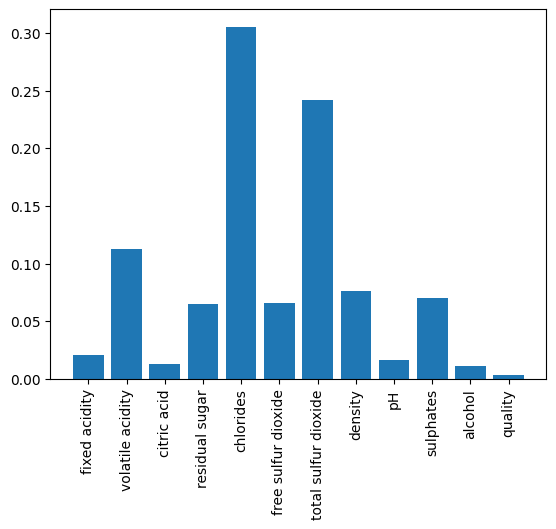

In [31]:
plt.bar(feature_names, height=importances)
plt.xticks(rotation=90);
# note: quality is not important for classification: white and red wines can be of high quality! 

#### Area under the curve (classification metrics)

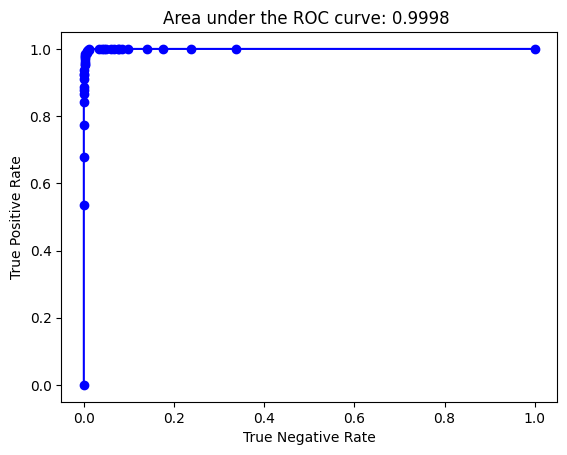

In [32]:
###############################################
####### PART 2 - for RECORDING ################
###############################################

# let's see now the Receiver Operating Curve (ROC) and the corresponding area (= AUC)

decision_function = rf.predict_proba(X_test_s)[:,1] # change 1 by 0 for using the negative class
# This info is used to build the ROC curve, where different thresholds are using while accuracy is monitored

TPR, TNR, thresholds = roc_curve(y_test, decision_function, pos_label='red') 
# TNR (= True Negative Rate) = TN / (TN + FP)
# TPR (= True Positive Rate) = TP / (TP + FN)

area_under_curve = auc(TNR, TPR) # area under the ROC curve (function "auc()", imported from sklearn)

# plot the ROC curve
plt.plot(TNR, TPR,'bo-')
plt.title(f'Area under the ROC curve: {area_under_curve:.4f} ')
plt.xlabel('True Negative Rate')
plt.ylabel('True Positive Rate');

### Let's check some trees

In [33]:
# Let's decrease the maximum depth of the tree to facilitate visualization:
rf = RandomForestClassifier(max_depth=3)
rf.fit(X_train_s, y_train)

RandomForestClassifier(max_depth=3)

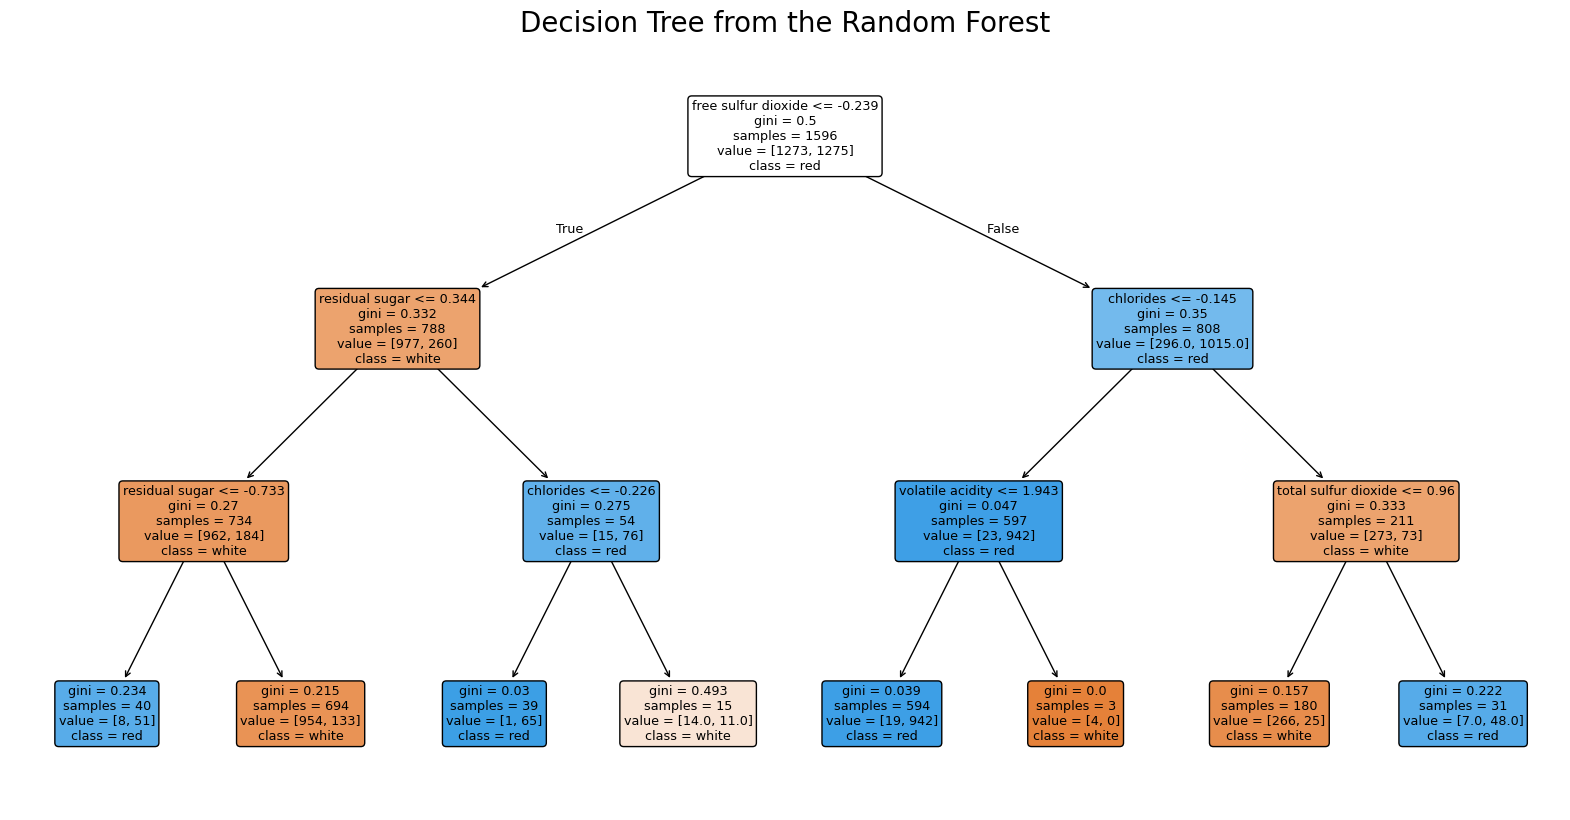

In [34]:
tree = rf.estimators_[0] # Let's visualize the first tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=feature_names,  # List of your feature names
    class_names=['white', 'red'],      # List of your class labels
    filled=True,
    rounded=True
)
plt.title("Decision Tree from the Random Forest", fontsize=20);
# plt.savefig('tree1.pdf', dpi=600) # uncomment this line to save your tree

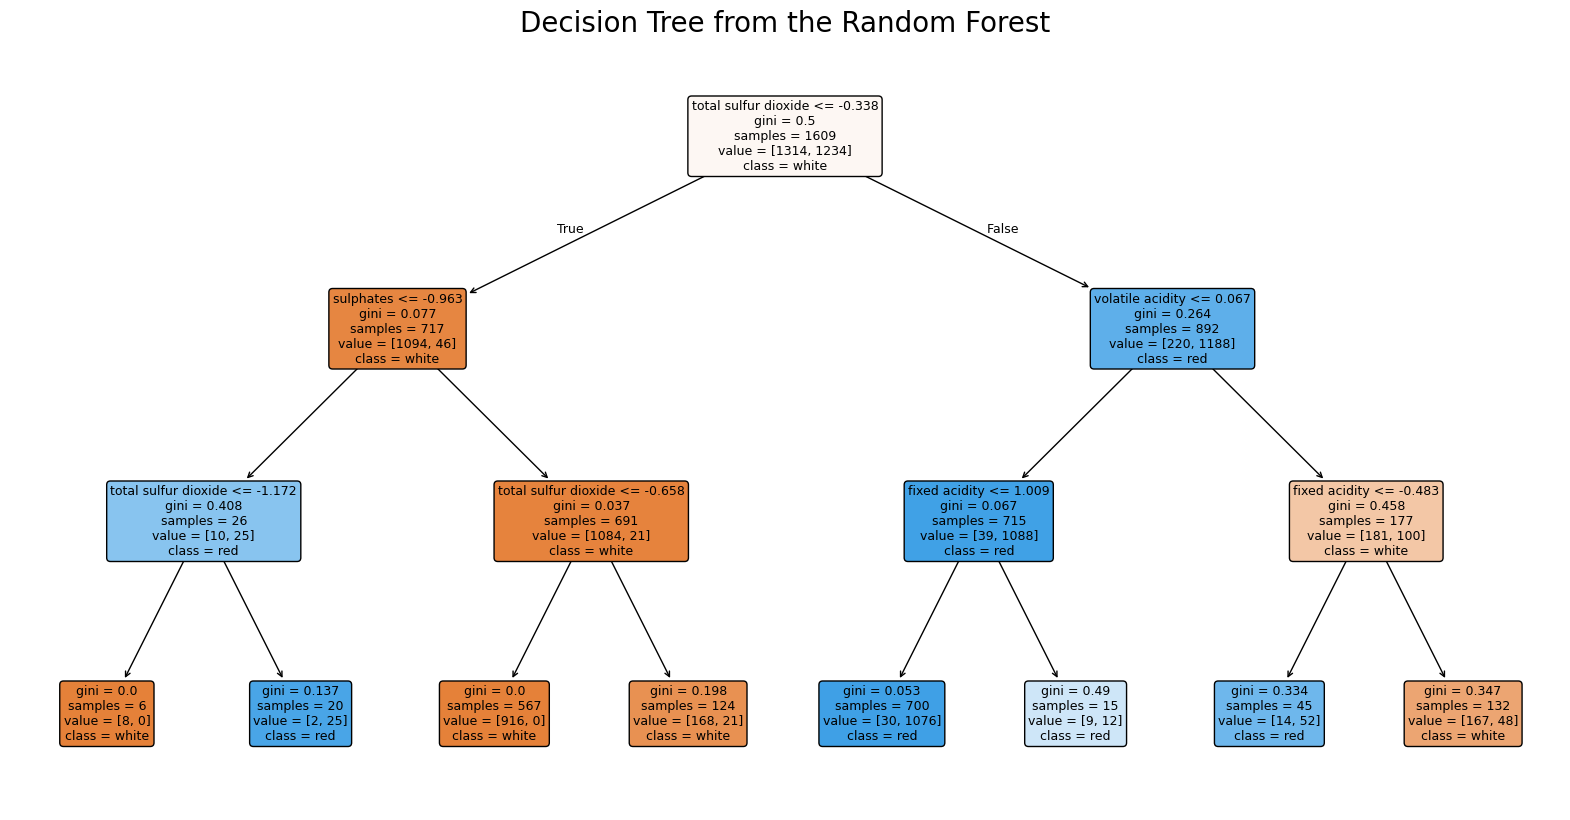

In [35]:
tree = rf.estimators_[-1] # Let's visualize the last tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=feature_names,  # List of your feature names
    class_names=['white', 'red'],      # List of your class labels
    filled=True,
    rounded=True
)
plt.title("Decision Tree from the Random Forest", fontsize=20);
# plt.savefig('tree1.pdf', dpi=600) # uncomment this line to save your tree

# Instead of predicting the wine type, predict the wine quality using all other features (show the final accuracy for this multi-class classification task)

In [36]:
# To use column "type" as a feature in our classification, convert "red" = 0 and "white" = 1, otherwise
# we cannot include this column in our model (we need numbers!)

myencoder = LabelEncoder()

col_type = data_cured['type'] # column I want to encode as 0 and 1
col_encoded = myencoder.fit_transform(col_type)

data_cured['type'] = col_encoded # update/redefine column "type" with new (encoded) values

In [37]:
myencoder.classes_ # check classes ('red' = 0, 'white' = 1) 

array(['red', 'white'], dtype=object)

In [38]:
# check the data again (your target property is the column 'quality'
data_cured.head() # now column "type" contains only 0's and 1's and is a simple feature

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
5305,0,12.0,0.39,0.66,3.0,0.093,12.0,30.0,0.99960,3.18,0.63,10.8,7
72,1,6.0,0.27,0.28,4.8,0.063,31.0,201.0,0.99640,3.69,0.71,10.0,5
5306,0,10.4,0.34,0.58,3.7,0.174,6.0,16.0,0.99700,3.19,0.70,11.3,6
3669,1,5.9,0.37,0.32,1.6,0.029,41.0,102.0,0.98916,3.41,0.55,12.7,7
4912,0,8.9,0.62,0.18,3.8,0.176,52.0,145.0,0.99860,3.16,0.88,9.2,5


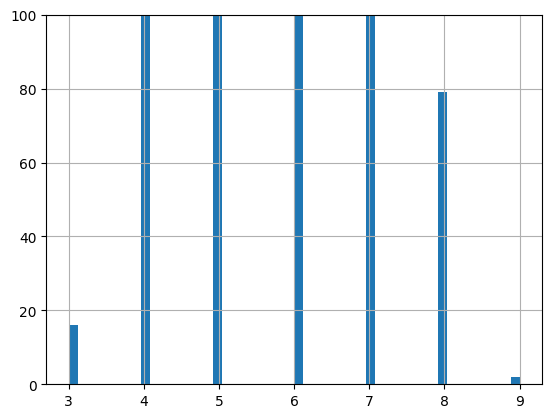

In [41]:
# Check how balanced is the dataset: How many samples each class has? You can make a histogram of column 'quality'. 
# If any class has less than 20 samples, eliminate these samples.
# Also note: The model accuracy will be worse for classes with fewer elements...
data_cured['quality'].hist(bins=50)
plt.ylim(0,100);

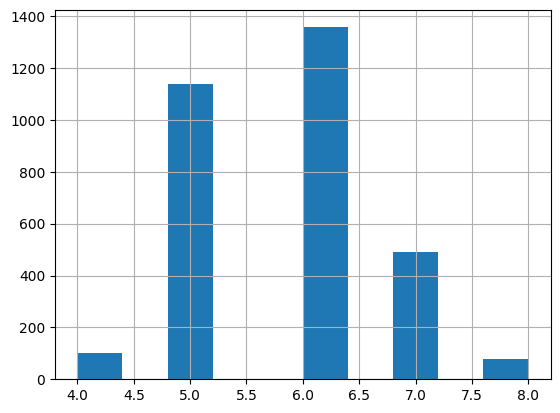

In [51]:
# Note: classes 3 and 9 have less than 20 samples. let's eliminate all samples having these classes
mask1 = data_cured['quality'] > 3
mask2 = data_cured['quality'] < 9
data_cured_new = data_cured[mask1 & mask2]
data_cured_new['quality'].hist(); # check that classes 3 and 9 were indeed removed

In [52]:
data_cured_new

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
5305,0,12.0,0.39,0.66,3.00,0.093,12.0,30.0,0.99960,3.18,0.63,10.8,7
72,1,6.0,0.27,0.28,4.80,0.063,31.0,201.0,0.99640,3.69,0.71,10.0,5
5306,0,10.4,0.34,0.58,3.70,0.174,6.0,16.0,0.99700,3.19,0.70,11.3,6
3669,1,5.9,0.37,0.32,1.60,0.029,41.0,102.0,0.98916,3.41,0.55,12.7,7
4912,0,8.9,0.62,0.18,3.80,0.176,52.0,145.0,0.99860,3.16,0.88,9.2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,1,6.4,0.21,0.34,16.05,0.040,56.0,142.0,0.99678,3.11,0.38,10.6,5
5105,0,7.8,0.57,0.31,1.80,0.069,26.0,120.0,0.99625,3.29,0.53,9.3,5
6083,0,7.0,0.43,0.30,2.00,0.085,6.0,39.0,0.99346,3.33,0.46,11.9,6
5952,0,8.2,0.64,0.27,2.00,0.095,5.0,77.0,0.99747,3.13,0.62,9.1,6


In [53]:
# Define your dataset: features (X) and target (y)

# the target vector will be the column "quality"
X = data_cured_new.drop(['quality'], axis = 1) # features are all columns except the target column
y = data_cured_new['quality'] # classes (=white or red)

In [54]:
# Split your dataset (20% for the test set)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [55]:
# Preprocess the features

scaler = StandardScaler()
scaler.fit(X_train) #mean and std of each feature of X_train are stored inside object "scaler"
X_train_s = scaler.transform(X_train) # convert X_train into zero mean and unit variance
X_test_s = scaler.transform(X_test) # convert X_test into zero mean and unit variance

In [56]:
# Create and train the RF model (use default hyperparameters)

rf = RandomForestClassifier() # create the model (with 100 trees by default)
rf.fit(X_train_s, y_train) # train the model (optimize splitting parameters for all (100) trees)


RandomForestClassifier()

In [57]:
# Perform predictions on the test set

pred = rf.predict(X_test_s) # perform predictions


In [58]:
# Calculate the accuracy (for predictions on the test set)

acc = rf.score(X_test_s, y_test) # number of correct classifications / total number of classifications
print(f'accuracy: {acc*100:.2f}%')


accuracy: 66.88%


In [59]:
# Show a classification report


report = classification_report(y_test, pred) 
print(report) # without the 'stratify' parameter used during dataset splitting, the 'support' below would be different for both classes



              precision    recall  f1-score   support

           4       1.00      0.05      0.10        20
           5       0.70      0.76      0.73       228
           6       0.65      0.73      0.69       272
           7       0.64      0.50      0.56        98
           8       1.00      0.12      0.22        16

    accuracy                           0.67       634
   macro avg       0.80      0.43      0.46       634
weighted avg       0.69      0.67      0.65       634



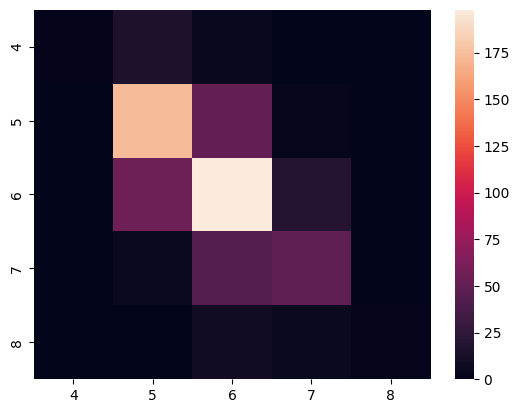

In [60]:
# Get a confusion matrix and visualize it using the seaborn library 

conf_mat = confusion_matrix(y_test, pred)    # Your code here
import seaborn as sns # library based on matplotlib to easily make nice plots
classes = ['4','5','6','7','8']
sns.heatmap(conf_mat, yticklabels=classes, xticklabels=classes);

<Br><Br>
# TASK: Repeat the previous task using regression instead of classification and show regression metrics and a parity plot.
<Br><Br>

In [61]:
# the training and test sets were already defined and can be reused here
rf = RandomForestRegressor() # create the model (with 100 trees by default)
rf.fit(X_train_s, y_train) # train the model (optimize splitting parameters for all (100) trees)

RandomForestRegressor()

In [62]:
pred = rf.predict(X_test_s) # perform predictions
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f'MAE: {mae:.2f}, R2: {r2:.2f}')

MAE: 0.45, R2: 0.46


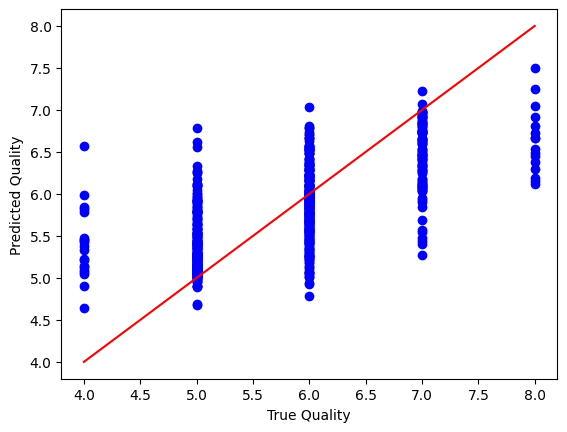

In [64]:
plt.plot(y_test, pred, 'bo')
low,high = y_test.min(), y_test.max()
plt.plot([low,high], [low,high], '-r')
plt.xlabel('True Quality')
plt.ylabel('Predicted Quality');
# NOTE: It is MUCH better to use a classifier for this problem!

## HOMEWORK
Make a binary classification of the wine type (white or red). Use a for loop to train a RF model using different number of trees (e.g. from 1 to 30) and plot the final classification accuracy as a function of the number of trees. Tip: use the same random state inside the model to keep consistency.

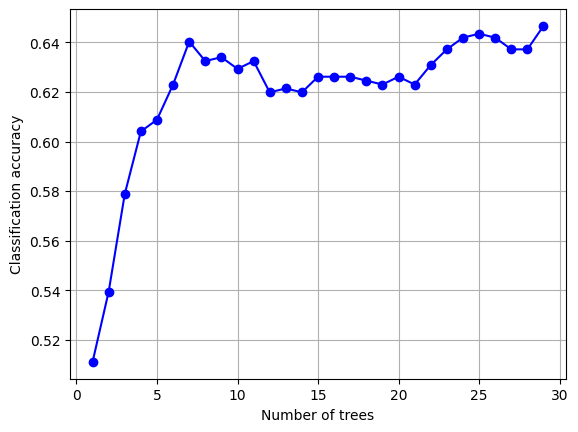

In [65]:
accs = []
n_trees = np.arange(1,30)
for n in n_trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train_s, y_train)
    acc = model.score(X_test_s, y_test)
    accs.append(acc)

plt.plot(n_trees, accs, '-bo')
plt.xlabel('Number of trees')
plt.ylabel('Classification accuracy')
plt.grid()

# Challenge
Repeat the procedure above using 10 different random states inside the RF model for each number of trees used, so that you can plot the results showing error bars corresponding to the standard deviation of the accuracy.

In [66]:
n_trees = np.arange(1,30)
results = []
for n in n_trees:
    accs = []
    for seed in [11,13,17,19,23,29,31,37,41,43]:
        model = RandomForestClassifier(n_estimators=n, random_state=seed)
        model.fit(X_train_s, y_train)
        acc = model.score(X_test_s, y_test)
        accs.append(acc)
    acc_avg = np.mean(accs)
    acc_std = np.std(accs)
    results.append([acc_avg, acc_std])

results = np.array(results)
acc = results[:,0]
std = results[:,1]

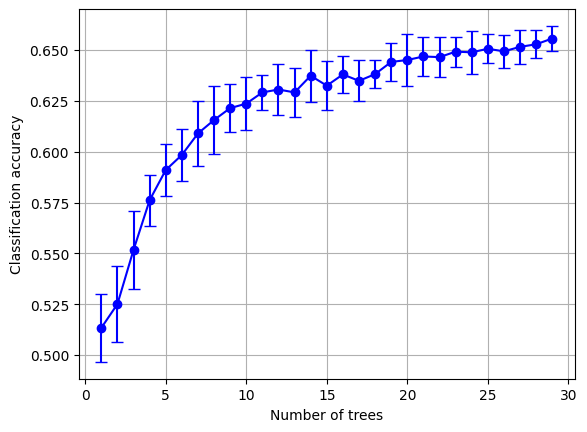

In [67]:
plt.errorbar(n_trees, acc, yerr=std, fmt = '-bo', capsize=4)
plt.xlabel('Number of trees')
plt.ylabel('Classification accuracy')
plt.grid()

In [68]:
import os
os.getcwd()

'/home/rodrigo/Dropbox/dados/cursos/ministrados/ubt/machine_learning_basics'